In [2]:
import pandas as pd

train = pd.read_csv('/Users/apple/Downloads/archive (13)/train.csv')
stores = pd.read_csv('/Users/apple/Downloads/archive (13)/stores.csv')
features = pd.read_csv('/Users/apple/Downloads/archive (13)/features.csv')

df = pd.merge(train, stores, on='Store', how='left')

df = pd.merge(df, features, on=['Store', 'Date'], how='left')

df['Date'] = pd.to_datetime(df['Date'])

print("Files Merged Successfully.")
print(f"Columns available: {list(df.columns)}")

Files Merged Successfully.
Columns available: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y']


/var/folders/g0/lxz8gk8x2bv0n5hs9p6ws6mm0000gn/T/ipykernel_23857/4130414954.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Type', y='Weekly_Sales', palette='Blues_d')


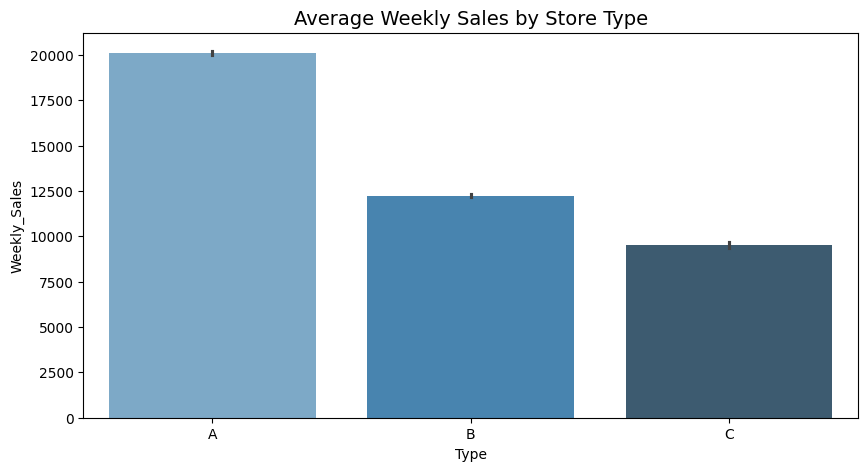

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df.drop(columns=['IsHoliday_y'])
df = df.rename(columns={'IsHoliday_x': 'IsHoliday'})

# Analysis: Which Store Type (A, B, C) actually performs best?
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Type', y='Weekly_Sales', palette='Blues_d')
plt.title('Average Weekly Sales by Store Type', fontsize=14)
plt.show()

Insight: Type A stores significantly outperform B and C in volume.

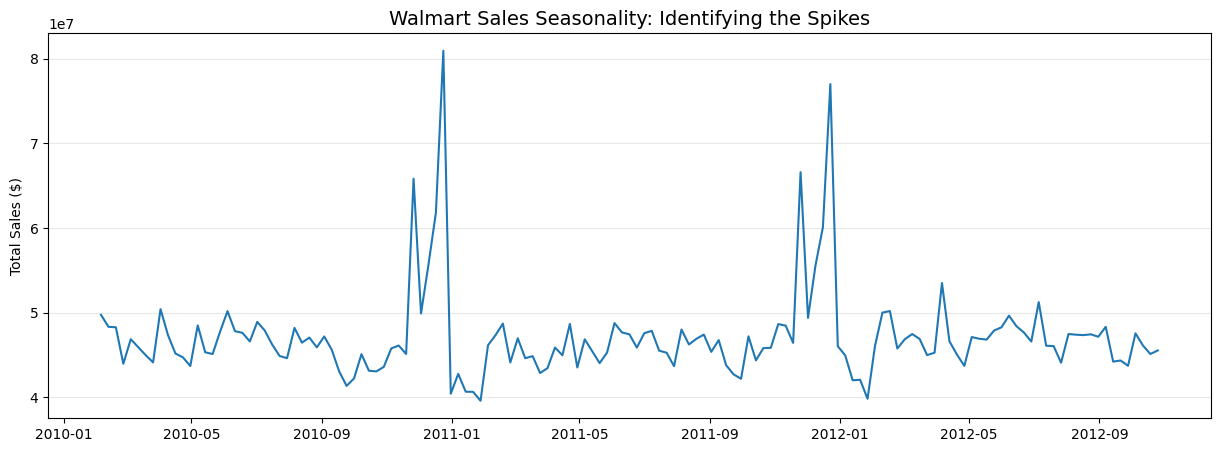

In [4]:
# Group by date to see the total timeline of sales
total_trend = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(total_trend['Date'], total_trend['Weekly_Sales'])
plt.title('Walmart Sales Seasonality: Identifying the Spikes', fontsize=14)
plt.ylabel('Total Sales ($)')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [5]:
# 1. Cleaning: Fill missing MarkDown values with 0 (as they represent no discount)
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

# 2. Analysis: Which Store has the highest total sales?
total_sales_per_store = df.groupby('Store')['Weekly_Sales'].sum()
max_sales_store = total_sales_per_store.idxmax()
max_sales_value = total_sales_per_store.max()

# 3. Analysis: Which Store has the maximum Standard Deviation (most fluctuation)?
std_sales_per_store = df.groupby('Store')['Weekly_Sales'].std()
max_std_store = std_sales_per_store.idxmax()

print(f"Store with Highest Total Sales: Store {max_sales_store} (${max_sales_value:,.2f})")
print(f"Store with Max Fluctuation (Std Dev): Store {max_std_store}")

Store with Highest Total Sales: Store 20 ($301,397,792.46)
Store with Max Fluctuation (Std Dev): Store 14


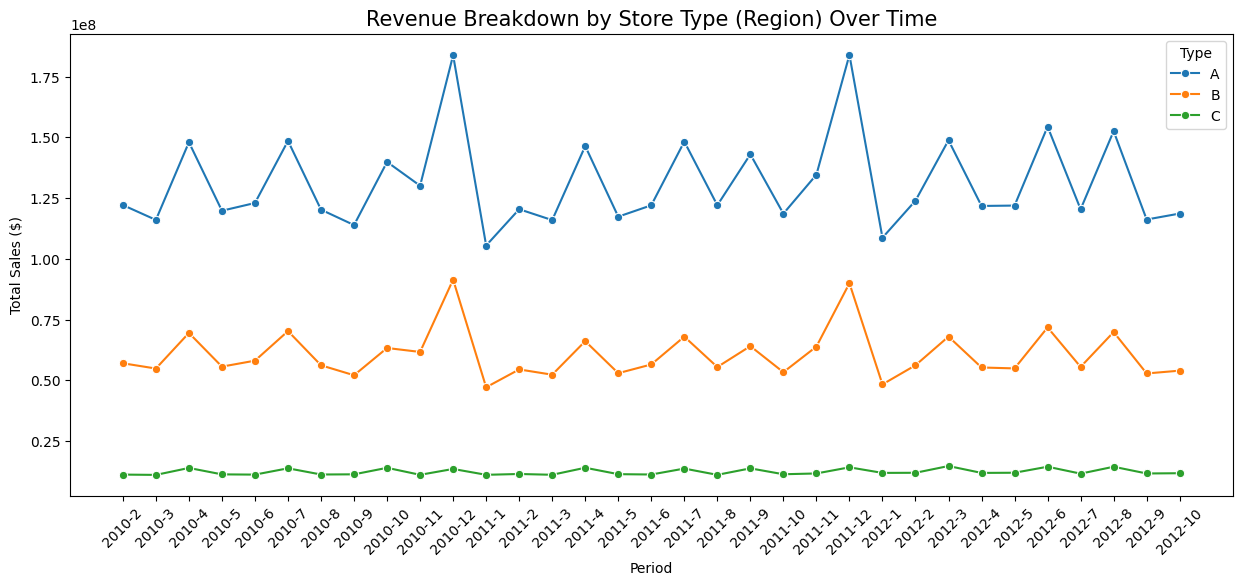

In [6]:
# 1. Feature Engineering: Extract Month and Year for 'Over Time' analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# 2. Revenue by 'Product' (Department) - Top 10 Departments
top_depts = df.groupby('Dept')['Weekly_Sales'].sum().nlargest(10).index
df_top_depts = df[df['Dept'].isin(top_depts)]

# 3. Revenue by 'Region' (Store Type) over Time
monthly_revenue = df.groupby(['Year', 'Month', 'Type'])['Weekly_Sales'].sum().reset_index()
# Create a 'Period' column for easier plotting
monthly_revenue['Period'] = monthly_revenue['Year'].astype(str) + '-' + monthly_revenue['Month'].astype(str)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_revenue, x='Period', y='Weekly_Sales', hue='Type', marker='o')
plt.title('Revenue Breakdown by Store Type (Region) Over Time', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Total Sales ($)')
plt.show()

In [7]:
def prepare_features(df_input):
    df_input['Date'] = pd.to_datetime(df_input['Date'])
    df_input['Year'] = df_input['Date'].dt.year
    df_input['Month'] = df_input['Date'].dt.month
    df_input['Week'] = df_input['Date'].dt.isocalendar().week.astype(int)
    df_input['Day'] = df_input['Date'].dt.day
    return df_input

df = prepare_features(df)

# Convert 'Type' (A, B, C) into numbers so the model can process it
df['Type'] = df['Type'].replace({'A': 1, 'B': 2, 'C': 3})

print("Year, Month, Week, and Day extracted.")

Year, Month, Week, and Day extracted.


/var/folders/g0/lxz8gk8x2bv0n5hs9p6ws6mm0000gn/T/ipykernel_23857/3685428951.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Type'] = df['Type'].replace({'A': 1, 'B': 2, 'C': 3})


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Select the features that impact sales
features_list = ['Store', 'Dept', 'IsHoliday', 'Type', 'Size', 'Week', 'Year']
X = df[features_list]
y = df['Weekly_Sales']

# Data Splitting
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train
model = RandomForestRegressor(n_estimators=20, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Check accuracy
accuracy = model.score(X_val, y_val)
print(f"Model Training Complete. Accuracy (R^2 Score): {accuracy:.2%}")

Model Training Complete. Accuracy (R^2 Score): 97.54%


/var/folders/g0/lxz8gk8x2bv0n5hs9p6ws6mm0000gn/T/ipykernel_23857/2662592452.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_merged['Type'] = test_merged['Type'].replace({'A': 1, 'B': 2, 'C': 3})


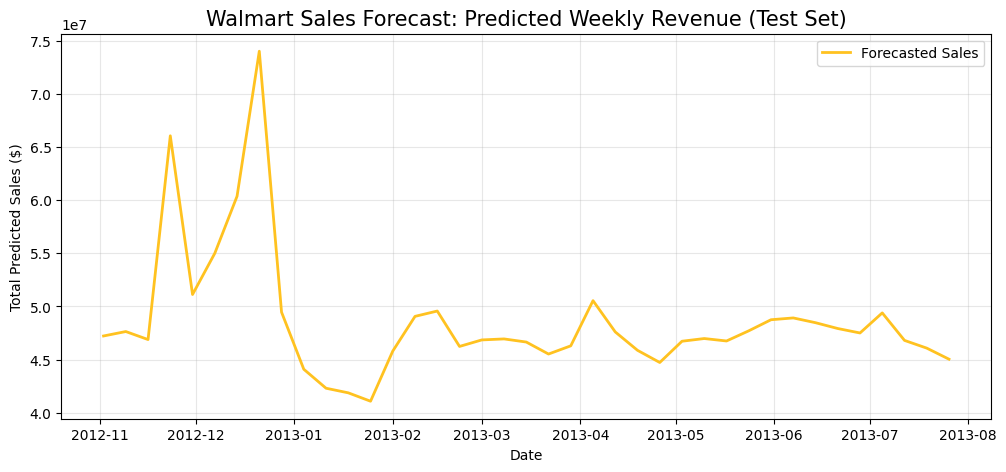

In [10]:
# 1. Load and Merge Test data
test = pd.read_csv('/Users/apple/Downloads/archive (13)/test.csv')
test_merged = pd.merge(test, stores, on='Store', how='left')
test_merged = pd.merge(test_merged, features, on=['Store', 'Date'], how='left')

if 'IsHoliday_x' in test_merged.columns:
    test_merged = test_merged.rename(columns={'IsHoliday_x': 'IsHoliday'})
    # Drop the duplicate holiday column if it exists
    if 'IsHoliday_y' in test_merged.columns:
        test_merged = test_merged.drop(columns=['IsHoliday_y'])

test_merged = prepare_features(test_merged)

test_merged['Type'] = test_merged['Type'].replace({'A': 1, 'B': 2, 'C': 3})
test_merged['Type'] = pd.to_numeric(test_merged['Type'])

# Predict
X_test = test_merged[features_list]
test_merged['Predicted_Sales'] = model.predict(X_test)

# 4. Final Visualization
forecast_trend = test_merged.groupby('Date')['Predicted_Sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(forecast_trend['Date'], forecast_trend['Predicted_Sales'], color='#ffc220', linewidth=2, label='Forecasted Sales')
plt.title('Walmart Sales Forecast: Predicted Weekly Revenue (Test Set)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Total Predicted Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

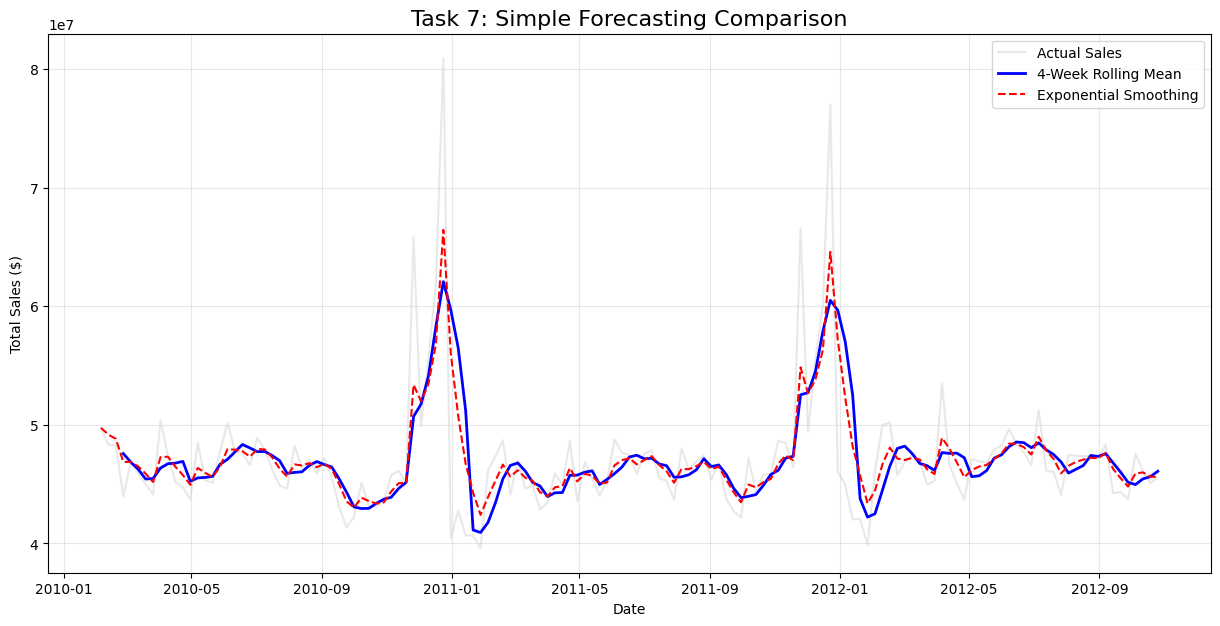

Simple Forecasting models (Rolling Mean & Exponential Smoothing) implemented.


In [11]:
import matplotlib.pyplot as plt

# 1. Prepare the total weekly sales trend from the training data
total_trend = df.groupby('Date')['Weekly_Sales'].sum().sort_index()

# 2. Simple Forecasting: Rolling Mean (Moving Average)
rolling_mean = total_trend.rolling(window=4).mean()

# 3. Simple Forecasting: Exponential Smoothing
exp_smoothing = total_trend.ewm(span=4, adjust=False).mean()

# 4. Plotting the Results
plt.figure(figsize=(15, 7))
plt.plot(total_trend.index, total_trend.values, label='Actual Sales', color='lightgray', alpha=0.5)
plt.plot(rolling_mean.index, rolling_mean.values, label='4-Week Rolling Mean', color='blue', linewidth=2)
plt.plot(exp_smoothing.index, exp_smoothing.values, label='Exponential Smoothing', color='red', linestyle='--')

plt.title('Task 7: Simple Forecasting Comparison', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Simple Forecasting models (Rolling Mean & Exponential Smoothing) implemented.")